# 05 German Credit Cross Validation

## Reading this notebook

Notebook 05 is the cross-validation notebook. The first four notebooks developed,
validated, and documented a credit risk model on Lending Club data. This notebook
asks a different question: does the *mitigation technique* that was applied on
Lending Club transfer to a structurally different dataset?

**What is being tested, precisely:**

Not the model itself — German Credit is a different population with different
features and a different outcome base rate. What is being tested is the *method*:
does removing a proxy feature reduce disparate impact on an independent dataset,
the way it did on Lending Club?

**Why cross-validation matters for a fairness claim:**

A fairness finding on one dataset is a finding, not a principle. The remediation
article this project follows describes a five-stage loop — identify, mitigate,
validate, document, monitor. The "monitor" stage, at its most rigorous, asks
whether a fix continues to work when the population changes. A mitigation that
only works on the data where it was discovered is not a solution; it is an
artifact of that data.

This notebook is the test of whether the technique is a principle or an artifact.

**The claim, stated plainly:**

> "The proxy-removal fairness mitigation generalizes across populations."

**What the output will show, and how to read it carefully:**

The mitigation improved DI on German Credit by a small amount — from 0.9375 to
0.9697, a change of about 0.03. The notebook's interpretation correctly calls this
"small." But it is worth understanding *why* it is small, because it bears on what
the test actually establishes:

- On Lending Club, the baseline DI was 0.244 — severely unfair. The mitigation
  moved it to 0.798 — a swing of 0.55 in the regime where it matters.
- On German Credit, the baseline DI is 0.9375 — already considered fair. There is
  almost no room for improvement, because the model was not unfair to begin with.

In other words, the German Credit test shows the technique **does not harm**
fairness on an independent population, and nudges it slightly further toward
parity. It does **not** show that the technique rescues a severely unfair model —
because the baseline was not severely unfair. The two situations are not
equivalent, and the interpretation should be read with that distinction in mind.

**The phases:**

- Phases 1–2: setup and decision documentation
- Phase 3: loading German Credit
- Phase 4: cleaning, encoding, and preserving the protected attribute
- Phase 5: train/test split
- Phase 6: baseline model
- **Phase 7: the fairness metrics function** (the methodology being cross-validated)
- Phase 8: baseline fairness assessment
- **Phase 9: proxy-removal mitigation test** (the technique being cross-validated)
- **Phase 10: cross-validation summary** — the comparison table that is the artifact
- Phases 11–12: visualization and save

**The three things this notebook establishes:**

1. **The methodology transfers.** DI, DPD, and EOD can be computed on a different
   dataset with a different protected attribute, using the same functions.
2. **The mitigation technique transfers.** Proxy removal did not harm fairness on
   German Credit, and improved DI marginally.
3. **The magnitude does not transfer, and cannot be tested this way.** The German
   Credit baseline was already fair; the test does not exercise the mitigation
   under the conditions where it matters most.

**What the notebook does not do, and should not be expected to do:**

It does not prove that the Lending Club mitigation would work on any bank's
portfolio. It does not prove that removing state features would help a Canadian
lender facing a similar geographic disparity. It proves something narrower: that
the technique is not specific to Lending Club — it is a technique, not an
accident of one dataset.

## PHASE 1: ENVIRONMENT SETUP

### Why this phase exists

Same reproducibility convention as every prior notebook: a fixed seed, a fixed
set of libraries, a fixed directory structure.

**One library worth noting:** `fairlearn` is used here for the first time in the
series. The previous notebooks computed disparate impact and related metrics by
hand, using base rates and confusion matrix counts. This notebook uses the
`fairlearn` library, which provides `demographic_parity_ratio`,
`demographic_parity_difference`, `equalized_odds_difference`, and the
`MetricFrame` class for group-level breakdowns.

**Why this is worth flagging:** the metrics should be identical whichever way
they are computed — the formula for DI does not change with the library. Using
`fairlearn` here is a reasonable choice (it is a standard fairness library), but
it means the numbers in this notebook should be compared to the Lending Club
numbers with the understanding that the implementations differ. A cross-
validation of the *methodology* is strongest when the methodology is implemented
identically. If you have time, computing DI both ways (by hand, and with
`fairlearn`) and confirming they match would strengthen the cross-validation.

In [1]:
# ============================================================================
# PHASE 1: ENVIRONMENT SETUP
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 1: ENVIRONMENT SETUP")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

# Machine learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Fairness
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    MetricFrame,
    selection_rate,
    true_positive_rate,
)

# Display
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

# Directories
os.makedirs("outputs/figures/german_credit", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)

# Project-wide random seed (mirrors Lending Club)
RANDOM_STATE = 42
print(f"[OK] Project-wide random seed: {RANDOM_STATE}")
print("[OK] Phase 1 Complete")


PHASE 1: ENVIRONMENT SETUP
[OK] Project-wide random seed: 42
[OK] Phase 1 Complete


## PHASE 2: DECISION DOCUMENTATION

### Why this phase exists

Five decision points are documented before any code runs: why German Credit,
why Random Forest, why the same metrics, why the same mitigation technique, and
why Sex as the protected attribute.

**The most consequential decision is the fourth** — "test proxy-feature removal,
one proxy at a time." This is the design that makes the cross-validation a test
of the *technique* rather than of a specific feature. On Lending Club, the proxy
was geography (state). German Credit has no geography. But it has other candidate
proxies — Housing, Job, Purpose — and removing each in turn is a way to ask
whether "remove a proxy feature" is a generalizable move.

**The fifth decision is also important, and slightly different in kind.** The
first four decisions are about making the comparison valid. The fifth — using
Sex, a direct protected attribute — is about making the fairness *measurement*
valid. On Lending Club, the protected class was a proxy (state for race/ethnicity).
On German Credit, it is direct (Sex is in the data). So the notebook is testing
the mitigation technique under cleaner measurement conditions than the original
finding had. That is a genuine strength, and it is worth noting that the two
notebooks are not perfectly symmetric: Lending Club tested the technique under
proxy measurement, German Credit tests it under direct measurement.

**What the phase does not document:** the possibility that the German Credit
baseline is already fair, and therefore that there is limited room for the
mitigation to demonstrate an effect. This is not a decision the phase needs to
justify in advance, but a reader arriving at Phase 10 will wish it had been
flagged earlier.

In [2]:
# ============================================================================
# PHASE 2: DECISION DOCUMENTATION
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 2: DECISION DOCUMENTATION")
print("=" * 80)

"""
DECISION POINT 1: WHY CROSS-VALIDATE ON GERMAN CREDIT
======================================================
Decision: Use German Credit as the independent cross-validation population.

Rationale:
1. Structurally different from Lending Club (German, 1970s-80s,
   1,000 records, 20 features) — a genuine independent test.
2. Contains direct protected attributes (Sex, Age, Foreign worker)
   that Lending Club lacked.
3. Publicly available, widely used, reproducible.

Limitation:
German Credit has NO geographic attribute. The Lending Club finding
(state as geographic proxy) cannot be cross-validated directly. What
is cross-validated is the methodology and the mitigation technique.

DECISION POINT 2: SAME MODEL CLASS ON BOTH DATASETS
====================================================
Decision: Use Random Forest on German Credit (matching the best model
          on Lending Club).

Rationale:
Cross-validation requires comparability. Using a different model class
on each dataset would confound the fairness finding with the model
choice. Random Forest was the Lending Club best model, so Random Forest
is used here.

DECISION POINT 3: SAME FAIRNESS METRICS ON BOTH DATASETS
=========================================================
Decision: Compute DI, DPD, and EOD — the same metrics used in the
          Lending Club validation.

Rationale:
The claim being tested is that the mitigation generalizes, not that
some other fairness metric behaves differently. Same metrics = comparable
results.

DECISION POINT 4: SAME MITIGATION TECHNIQUE
============================================
Decision: Test proxy-feature removal, one proxy at a time.

Rationale:
The Lending Club mitigation was to remove state features (a geographic
proxy). German Credit does not have geography, but it has other
candidate proxies (Housing, Job, Purpose). Removing each in turn tests
whether the mitigation technique generalizes.

DECISION POINT 5: PROTECTED ATTRIBUTE
======================================
Decision: Use Sex as the protected attribute (direct, present in data).

Rationale:
Sex is a direct protected attribute in German Credit. Using it avoids
the proxy problem entirely for the protected-class side of the test.
"""

print("[OK] Decision points documented")


PHASE 2: DECISION DOCUMENTATION
[OK] Decision points documented


## PHASE 3: DATA LOADING

### Why this phase exists

Loads the German Credit dataset — 1,000 rows, 11 columns, the classic UCI
dataset from the 1970s–80s.

**The column list is worth reading closely:** Age, Sex, Job, Housing, Saving
accounts, Checking account, Credit amount, Duration, Purpose, Risk. Compare that
to Lending Club's 56 columns, most of which were credit-bureau features.

**What the difference means for the cross-validation:** German Credit is a much
smaller, much simpler dataset. It has no credit score, no delinquency history, no
employment stability, no geographic information. The model it supports will
necessarily be less predictive, and the fairness analysis is necessarily simpler.

**Is that a limitation, or a feature?** Both. It limits what can be cross-validated
(no geography). But it also makes the test a genuine structural contrast — if the
mitigation technique transfers from a 56-feature U.S. consumer lending dataset to
a 10-feature German dataset from the 1980s, the technique is probably robust. That
is the value of using a structurally different population.

In [3]:
# ============================================================================
# PHASE 3: DATA LOADING
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 3: DATA LOADING")
print("=" * 80)

# Load German Credit data. Adjust path if your file is elsewhere.
data_path = Path("data/german_credit_data2.csv")
if not data_path.exists():
    data_path = Path("german_credit_data2.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "german_credit_data2.csv not found. Expected in data/ or repo root."
    )

df = pd.read_csv(data_path)
print(f"[OK] Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"  Columns: {list(df.columns)}")
print(f"  First 5 rows:")
print(df.head())



PHASE 3: DATA LOADING
[OK] Loaded 1,000 rows, 11 columns
  Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']
  First 5 rows:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0           1169         6             radio/TV  good  
1           5951        48             radio/TV   bad  
2           2096        12            education  good  
3           7882        42  furniture/equipment  good  
4           4870        24                  

## PHASE 4: DATA CLEANING

### Why this phase exists

Four things happen: target encoding, missing-value handling, ordinal encoding for
the account columns, and one-hot encoding for Housing and Purpose.

**The most important line in this phase** is the one that preserves the protected
attribute before encoding:

```python
sex_series = (df["Sex"].astype(str).str.lower() == "male").astype(int)

In [4]:
# ============================================================================
# PHASE 4: DATA CLEANING
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 4: DATA CLEANING")
print("=" * 80)

# 4.1 Drop unnecessary index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print("[OK] Dropped 'Unnamed: 0'")

# 4.2 Target encoding
# The German Credit dataset uses "good" (low risk) and "bad" (high risk).
# For fairness testing, positive class = "good" (approved / low-risk).
if df["Risk"].dtype == object:
    df["Risk"] = df["Risk"].map({"good": 1, "bad": 0})
    print("[OK] Target encoded: good=1, bad=0")

print(f"\nTarget distribution:")
print(df["Risk"].value_counts(normalize=True).round(4))

# 4.3 Missing-value handling
# Saving accounts / Checking account have structural missingness
# (some applicants do not report). Preserve this as an explicit category.
for col in ["Saving accounts", "Checking account"]:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna("no_account")
        print(f"[OK] Filled missing values in '{col}' with 'no_account'")

missing_after = df.isnull().sum().sum()
print(f"Missing values after cleaning: {missing_after}")
assert missing_after == 0, "Missing values remain!"

# 4.4 Protect the Sex column before encoding
# We need Sex as a separate series for fairness testing.
if "Sex" not in df.columns:
    raise ValueError("Sex column not found — cannot perform fairness testing.")

# Preserve Sex as a binary indicator BEFORE one-hot encoding.
# Convention: Sex_male = 1 for male, 0 for female (mirrors standard encoding).
sex_series = (df["Sex"].astype(str).str.lower() == "male").astype(int)
sex_series.name = "Sex_male"
print(f"\nProtected attribute preserved: Sex_male")
print(f"  Group counts:\n{sex_series.value_counts().to_dict()}")

# 4.5 Encoding
# Ordinal encoding for Saving accounts / Checking account (they have
# a natural order: little < moderate < quite rich < rich; unknown as base).
ordinal_map = {
    "no_account": 0,
    "little": 1,
    "moderate": 2,
    "quite rich": 3,
    "rich": 4,
}

for col in ["Saving accounts", "Checking account"]:
    if col in df.columns:
        df[col] = df[col].map(ordinal_map).fillna(0).astype(int)
        print(f"[OK] Ordinal-encoded '{col}'")

# One-hot encoding for nominal variables.
# IMPORTANT: we drop Sex from the feature matrix — it will be used only
# as the protected attribute, not as a model input (mirrors removing
# the protected proxy on Lending Club).
nominal_cols = [c for c in ["Housing", "Purpose"] if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=float)
print(f"[OK] One-hot encoded: {nominal_cols}")

# Drop original Sex column — it is not a feature.
df = df.drop(columns=["Sex"])
print("[OK] Dropped original 'Sex' column (used only as protected attribute)")

print(f"\nFinal preprocessed shape: {df.shape}")


PHASE 4: DATA CLEANING
[OK] Dropped 'Unnamed: 0'
[OK] Target encoded: good=1, bad=0

Target distribution:
Risk
1    0.7
0    0.3
Name: proportion, dtype: float64
[OK] Filled missing values in 'Saving accounts' with 'no_account'
[OK] Filled missing values in 'Checking account' with 'no_account'
Missing values after cleaning: 0

Protected attribute preserved: Sex_male
  Group counts:
{1: 690, 0: 310}
[OK] Ordinal-encoded 'Saving accounts'
[OK] Ordinal-encoded 'Checking account'
[OK] One-hot encoded: ['Housing', 'Purpose']
[OK] Dropped original 'Sex' column (used only as protected attribute)

Final preprocessed shape: (1000, 16)


## PHASE 5: TRAIN / TEST SPLIT


---

### Phase 5 note (Train/Test Split)

```markdown
### Why this phase exists

An 80/20 split with stratification on the target and preservation of the
protected attribute across the split. The test set is 200 rows, of which
approximately 60 are female and 140 are male.

**Why the split preserves `sex`:** the protected attribute must be available
on the test set for fairness analysis. If the split lost track of which rows
belonged to which group, the fairness metrics could not be computed.

**The sample-size consideration, stated plainly:** 200 test rows is small. The
female group has approximately 60 rows, the male group 140. Group-level selection
rates on 60 rows have meaningful sampling variance — a difference of a few
percentage points could easily be noise rather than a real disparity.

**This matters for interpretation more than for methodology.** The cross-validation
still answers the question "does the technique transfer?" But it answers it with
coarser precision than a larger dataset would allow. A finding of "DI moved from
0.94 to 0.97" on 200 rows should not be read as a precise effect size; it should
be read as "the technique did not make fairness worse, and may have improved it
slightly."

In [5]:
# ============================================================================
# PHASE 5: TRAIN / TEST SPLIT
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 5: TRAIN / TEST SPLIT")
print("=" * 80)

X = df.drop(columns=["Risk"])
y = df["Risk"]

# Preserve Sex alignment through the split
sex = sex_series.loc[X.index]

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"[OK] Train: {len(X_train):,} rows, default rate {y_train.mean():.2%}")
print(f"[OK] Test:  {len(X_test):,} rows, default rate {y_test.mean():.2%}")
print(f"[OK] Sex preserved for fairness testing on the test set")

# Feature names for later
feature_cols = X_train.columns.tolist()


PHASE 5: TRAIN / TEST SPLIT
[OK] Train: 800 rows, default rate 70.00%
[OK] Test:  200 rows, default rate 70.00%
[OK] Sex preserved for fairness testing on the test set


## PHASE 6: BASELINE MODEL — RANDOM FOREST (mirrors Lending Club best model)

### Why this phase exists

A Random Forest classifier is trained on German Credit, mirroring the model class
used as the best model on Lending Club.

**Why the same model class matters:** the claim being tested is about the
mitigation technique, not about the model. If Lending Club used Random Forest and
German Credit used a different model class, a change in DI could be attributed to
the model change rather than the mitigation. Same model class = comparable test.

**What the output shows:**

- CV AUC: 0.7596 (±0.1338)
- Test AUC: 0.7415
- Accuracy: 0.66
- Precision: 0.8529 (on the "good" class)
- Recall: 0.6214

**The CV standard deviation is worth noting:** ±0.13 is large. That reflects both
the small dataset size (800 training rows) and the inherent difficulty of the
problem. The test AUC of 0.7415 is higher than Lending Club's 0.621, but on a
much easier problem — German Credit is a simplified dataset with fewer features
and a stronger signal.

**One framing note on the performance metrics:** the positive class is "good"
(creditworthy), not "bad" (default). So precision of 0.85 means "of applicants
predicted creditworthy, 85% are." That is the fairness-relevant framing (approval
rates are what DI measures), but it is inverted relative to how a credit model's
performance is usually reported. A reader comparing this to Lending Club's
precision of 0.03 should note the two are on opposite classes.

In [6]:
# ============================================================================
# PHASE 6: BASELINE MODEL — RANDOM FOREST (mirrors Lending Club best model)
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 6: BASELINE MODEL TRAINING")
print("=" * 80)

"""
DECISION POINT 6: CLASS IMBALANCE HANDLING
===========================================
Decision: Use class_weight='balanced' (not SMOTE).

Rationale:
1. Mirrors the Lending Club approach (balanced class weights, not SMOTE).
2. SMOTE generates synthetic data, which is a regulatory concern.
3. Class-weighted RF is transparent and reproducible.

Note: German Credit's class distribution is ~70/30 (good/bad), so
imbalance is mild compared to Lending Club. Balanced weights are still
applied for consistency with Lending Club.
"""

baseline_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# 5-fold CV for comparability with Lending Club
cv_scores = cross_val_score(
    baseline_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
)
print(f"[OK] 5-Fold CV AUC-ROC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

baseline_model.fit(X_train, y_train)

y_proba = baseline_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Performance metrics (mirrors Lending Club report)
baseline_perf = {
    "AUC-ROC": roc_auc_score(y_test, y_proba),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
}

print("\nBASELINE PERFORMANCE:")
for k, v in baseline_perf.items():
    print(f"  {k}: {v:.4f}")


PHASE 6: BASELINE MODEL TRAINING
[OK] 5-Fold CV AUC-ROC: 0.7596 (+/- 0.1338)

BASELINE PERFORMANCE:
  AUC-ROC: 0.7415
  Accuracy: 0.6600
  Precision: 0.8529
  Recall: 0.6214
  F1: 0.7190


## PHASE 7: FAIRNESS METRICS FUNCTION (mirrors Lending Club)

### Why this phase exists

This phase defines the fairness metrics function — DI, DPD, EOD, and the
by-group breakdown — that will be used for both the baseline and the mitigation
analysis.

**Why the metrics are the same as Lending Club's:** the claim being tested is
that the technique generalizes. If the metrics changed between datasets, a change
in the result could be attributed to the metric change rather than the technique.
Keeping the metrics identical — DI, DPD, EOD, and the 0.80/0.60 severity bands —
is what makes the cross-validation a test of the technique.

**The three metrics, briefly:**

- **Disparate Impact Ratio (DI)** — the ratio of the lowest group's selection
  rate to the highest group's. The 0.80 threshold comes from the four-fifths rule
  in U.S. fair lending law.
- **Demographic Parity Difference (DPD)** — the absolute difference between
  group selection rates. Zero means perfect parity.
- **Equal Opportunity Difference (EOD)** — the difference in true positive rates
  between groups. This is the metric that catches cases where DI looks fine but
  the model is actually less accurate for one group.

**Why all three matter:** DI is the headline metric, but it can be satisfied by
a model that is simply less accurate for everyone. EOD catches that. Reporting
three metrics rather than one is the right discipline, and mirroring that
discipline from Lending Club is part of what makes the cross-validation credible.

**What the function returns:** a dict with the metrics, the status (OK / MONITOR /
SEVERE), and the group-level breakdown. The status thresholds are the same as
Lending Club's — DI ≥ 0.80 is OK, 0.60–0.80 is MONITOR, below 0.60 is SEVERE.

In [7]:
# ============================================================================
# PHASE 7: FAIRNESS METRICS FUNCTION (mirrors Lending Club)
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 7: FAIRNESS METRICS FUNCTION")
print("=" * 80)

def compute_fairness_metrics(y_true, y_pred, sensitive_features, name):
    """
    Compute DI, DPD, and EOD — the same metrics used in the Lending Club
    validation. Returns a dict with the metrics and the by-group breakdown.
    """
    di = demographic_parity_ratio(
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features
    )
    dpd = demographic_parity_difference(
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features
    )
    eod = equalized_odds_difference(
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features
    )

    mf = MetricFrame(
        metrics={
            "selection_rate": selection_rate,
            "tpr": true_positive_rate,
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_features,
    )

    # Interpret DI
    if di >= 0.80:
        di_status = "OK"
    elif di >= 0.60:
        di_status = "MONITOR"
    else:
        di_status = "SEVERE"

    print(f"\n{name} — Fairness Metrics")
    print(f"  Disparate Impact Ratio (DI):       {di:.4f}  [{di_status}]")
    print(f"  Demographic Parity Difference:      {dpd:.4f}")
    print(f"  Equal Opportunity Difference:       {eod:.4f}")
    print(f"\n  By group:")
    print(mf.by_group.round(4))

    return {
        "name": name,
        "DI": float(di),
        "DPD": float(dpd),
        "EOD": float(eod),
        "DI_Status": di_status,
        "by_group": mf.by_group,
    }



PHASE 7: FAIRNESS METRICS FUNCTION


## PHASE 8: BASELINE FAIRNESS ASSESSMENT

### Why this phase exists

This is the fairness profile of the baseline model — the model before any
mitigation is applied. It establishes the starting point against which the
mitigation effect will be measured.

**What the output shows:**

- DI = 0.9375 — classified as "OK"
- DPD = 0.0333
- EOD = 0.1500
- By group: female selection rate 0.5333, male selection rate 0.5000

**How to read these numbers, and why they matter:**

The baseline model is *already fair* on Sex. A DI of 0.9375 is well above the
0.80 threshold. There is no severe fairness problem on this dataset.

**This is the critical context for the whole notebook.** The Lending Club
baseline DI was 0.244 — a severe disparity that demanded mitigation. The German
Credit baseline DI is 0.9375 — a model that is already acceptable. The two
baselines are not comparable, and the mitigation cannot be expected to have
a comparable effect.

**The EOD of 0.150 is worth noting separately.** DI is about selection rates;
EOD is about accuracy within groups. An EOD of 0.15 means the model's true
positive rate differs by 15 percentage points between groups — female TPR 0.625,
male TPR 0.620. That is a smaller gap than it looks (the two TPRs are almost
identical), and the calculation may be sensitive to the small female sample.

**The honest reading:** the German Credit baseline is a fair model, with a
marginal disparity that is within the range of what the metrics call acceptable.
The mitigation test that follows is therefore not "can the technique fix a
problem?" but "does the technique change anything when there is no problem?"

In [8]:
# ============================================================================
# PHASE 8: BASELINE FAIRNESS ASSESSMENT
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 8: BASELINE FAIRNESS ASSESSMENT")
print("=" * 80)

baseline_fairness = compute_fairness_metrics(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sex_test,
    name="Baseline Random Forest (Sex)",
)


PHASE 8: BASELINE FAIRNESS ASSESSMENT

Baseline Random Forest (Sex) — Fairness Metrics
  Disparate Impact Ratio (DI):       0.9375  [OK]
  Demographic Parity Difference:      0.0333
  Equal Opportunity Difference:       0.1500

  By group:
          selection_rate    tpr
Sex_male                       
0                 0.5333  0.625
1                 0.5000  0.620


## PHASE 9: PROXY-REMOVAL MITIGATION TEST

### Why this phase exists

This is the core of the cross-validation. Three candidate proxies — Housing, Job,
Purpose — are removed in turn, the model is retrained, and DI is recomputed. The
result is a comparison of the baseline against each mitigation.

**What the output actually shows:** only `Job` was tested. The output line
"Testing proxy removal for: ['Job']" is the tell.

**Why the other two were skipped:** Phase 4 one-hot encoded `Housing` and
`Purpose` with `drop_first=True`, which renamed their columns to `Housing_own`,
`Housing_rent`, `Purpose_car`, etc. Phase 9's candidate filter checks whether the
literal name (`Housing`, `Purpose`) is in `X.columns`, and it is not — so those
two proxies are dropped from the candidate list. `Job` survives because it was
not one-hot encoded, so its column name is unchanged.

**The effect on the test:** what was designed as a three-way comparison became a
one-way comparison. The conclusion — "small improvement, technique generalizes
directionally" — rests on a single mitigation rather than three. A different
mitigation might have produced a different result.

**The fix:** change the candidate filter to match on both exact names and
prefixes:

```python
candidate_proxies = [
    c for c in ["Housing", "Job", "Purpose"]
    if c in X.columns or any(col.startswith(f"{c}_") for col in X.columns)
]

In [9]:
# ============================================================================
# PHASE 9: PROXY-REMOVAL MITIGATION TEST
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 9: PROXY-REMOVAL MITIGATION TEST")
print("=" * 80)

"""
DECISION POINT 7: CANDIDATE PROXIES
====================================
Decision: Test removal of Housing, Job, and Purpose.

Rationale:
These are the three features in German Credit that could plausibly carry
proxied protected-class information:
  - Housing: socioeconomic status proxy
  - Job: employment/income proxy
  - Purpose: life-stage/need proxy

Each is removed in turn, the model retrained, and DI recomputed. This
mirrors the Lending Club mitigation (remove state features) at the
technique level.
"""

def test_proxy_removal(
    X_train, y_train, X_test, y_test, sensitive_features,
    candidate_proxies, model_class, model_kwargs,
):
    """
    Baseline vs. one-proxy-removed-at-a-time. Returns a comparison table.
    """
    results = []

    # Baseline
    m = model_class(**model_kwargs)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    fm = compute_fairness_metrics(
        y_test, y_pred, sensitive_features, "Baseline (all features)"
    )
    results.append({
        "Intervention": "Baseline (all features)",
        "DI": fm["DI"],
        "DPD": fm["DPD"],
        "EOD": fm["EOD"],
        "DI_Status": fm["DI_Status"],
        "Features_Removed": 0,
    })

    # One proxy at a time
    for proxy in candidate_proxies:
        drop_cols = [
            c for c in X_train.columns
            if c == proxy or c.startswith(f"{proxy}_")
        ]
        if not drop_cols:
            print(f"[SKIP] No columns matching '{proxy}'")
            continue

        X_train_r = X_train.drop(columns=drop_cols)
        X_test_r = X_test.drop(columns=drop_cols)

        m = model_class(**model_kwargs)
        m.fit(X_train_r, y_train)
        y_pred = m.predict(X_test_r)

        fm = compute_fairness_metrics(
            y_test, y_pred, sensitive_features,
            f"Removed {proxy} ({len(drop_cols)} feature(s))"
        )
        results.append({
            "Intervention": f"Removed {proxy}",
            "DI": fm["DI"],
            "DPD": fm["DPD"],
            "EOD": fm["EOD"],
            "DI_Status": fm["DI_Status"],
            "Features_Removed": len(drop_cols),
        })

    return pd.DataFrame(results)


candidate_proxies = [c for c in ["Housing", "Job", "Purpose"] if c in X.columns]
print(f"Testing proxy removal for: {candidate_proxies}")

mitigation_results = test_proxy_removal(
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    sensitive_features=sex_test,
    candidate_proxies=candidate_proxies,
    model_class=RandomForestClassifier,
    model_kwargs={
        "n_estimators": 100,
        "max_depth": 6,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    },
)

print("\n" + "=" * 80)
print("PROXY-REMOVAL RESULTS")
print("=" * 80)
print(mitigation_results.round(4).to_string(index=False))


PHASE 9: PROXY-REMOVAL MITIGATION TEST
Testing proxy removal for: ['Job']

Baseline (all features) — Fairness Metrics
  Disparate Impact Ratio (DI):       0.9375  [OK]
  Demographic Parity Difference:      0.0333
  Equal Opportunity Difference:       0.1500

  By group:
          selection_rate    tpr
Sex_male                       
0                 0.5333  0.625
1                 0.5000  0.620

Removed Job (1 feature(s)) — Fairness Metrics
  Disparate Impact Ratio (DI):       0.9697  [OK]
  Demographic Parity Difference:      0.0167
  Equal Opportunity Difference:       0.0750

  By group:
          selection_rate    tpr
Sex_male                       
0                 0.5333  0.625
1                 0.5500  0.660

PROXY-REMOVAL RESULTS
           Intervention     DI    DPD   EOD DI_Status  Features_Removed
Baseline (all features) 0.9375 0.0333 0.150        OK                 0
            Removed Job 0.9697 0.0167 0.075        OK                 1


## PHASE 10: CROSS-VALIDATION SUMMARY — LENDING CLUB VS. GERMAN CREDIT


---

### Phase 10 note (Cross-Validation Summary)

```markdown
### Why this phase exists

This is the artifact: a side-by-side comparison of the Lending Club and German
Credit results. It is the table a reader will look at to decide whether the
technique generalizes.

**What the comparison shows:**

| | Lending Club | German Credit |
|---|---|---|
| Baseline DI | 0.2440 (SEVERE) | 0.9375 (OK) |
| Post-mitigation DI | 0.7980 (MONITOR) | 0.9697 (OK) |
| Delta DI | +0.5540 | +0.0322 |

**What the numbers say, and what they do not:**

The Lending Club mitigation moved DI by 0.55 — a large change in the regime where
it matters. The German Credit mitigation moved DI by 0.03 — a small change in a
regime where the model was already fair.

**The interpretation section correctly reads this as "small improvement," which
is honest. But there is a deeper point the comparison makes visible:** the two
mitigations are not being tested under comparable conditions. On Lending Club,
there was a problem to fix. On German Credit, there was not. The cross-validation
therefore answers a narrower question than "does the technique fix severe
unfairness?" — it answers "does the technique preserve fairness when applied to
an already-fair model?"

**What the artifact does support:** the technique is transferable in the sense
that removing a proxy feature does not damage fairness on an independent
population. That is a real result. It is weaker than "the technique fixes
unfairness everywhere," but it is also not nothing — a cross-population test that
showed the technique backfiring would be a serious finding.

**What a stronger cross-validation would require:** a dataset with a severe
baseline disparity on a direct protected attribute, so the mitigation can be
tested under conditions comparable to Lending Club. German Credit does not
provide that — its baseline is already fair. The notebook should say so, and
does, in its limitations section.

**The honest conclusion:** the technique generalizes in the sense that it can be
applied to a structurally different dataset without harm. Whether it generalizes
in the sense of *rescuing a severely unfair model* remains untested — and this
notebook is the right place to say so.

In [10]:
# ============================================================================
# PHASE 10: CROSS-VALIDATION SUMMARY — LENDING CLUB VS. GERMAN CREDIT
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 10: CROSS-VALIDATION SUMMARY")
print("=" * 80)

"""
The comparison table is the artifact. It answers the question:
did the mitigation improve DI on German Credit the way it did on
Lending Club?
"""

# Lending Club results (from the validation report)
lending_club_results = {
    "dataset": "Lending Club",
    "protected_attribute": "State (geographic proxy)",
    "baseline_DI": 0.244,
    "baseline_status": "SEVERE",
    "mitigation": "Removed 49 state features",
    "post_mitigation_DI": 0.798,
    "post_mitigation_status": "MONITOR",
    "delta_DI": 0.798 - 0.244,
}

# German Credit results (best-improving intervention)
best_intervention = mitigation_results.loc[
    mitigation_results["DI"].idxmax()
]

german_credit_results = {
    "dataset": "German Credit",
    "protected_attribute": "Sex (direct attribute)",
    "baseline_DI": float(mitigation_results.iloc[0]["DI"]),
    "baseline_status": mitigation_results.iloc[0]["DI_Status"],
    "mitigation": best_intervention["Intervention"],
    "post_mitigation_DI": float(best_intervention["DI"]),
    "post_mitigation_status": best_intervention["DI_Status"],
    "delta_DI": float(best_intervention["DI"] - mitigation_results.iloc[0]["DI"]),
}

comparison_df = pd.DataFrame([lending_club_results, german_credit_results])
print("\nCROSS-VALIDATION COMPARISON:")
print(comparison_df.round(4).to_string(index=False))

# Save comparison
comparison_df.to_csv(
    "outputs/reports/german_credit_cross_validation.csv",
    index=False,
)
print("\n[OK] Comparison saved to outputs/reports/german_credit_cross_validation.csv")

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(f"""
The claim being tested:
  "The proxy-removal fairness mitigation generalizes across populations."

Lending Club:
  Baseline DI:  {lending_club_results['baseline_DI']:.4f}  ({lending_club_results['baseline_status']})
  After mitigation:  {lending_club_results['post_mitigation_DI']:.4f}  ({lending_club_results['post_mitigation_status']})
  Delta DI:  +{lending_club_results['delta_DI']:.4f}

German Credit:
  Baseline DI:  {german_credit_results['baseline_DI']:.4f}  ({german_credit_results['baseline_status']})
  After mitigation ({german_credit_results['mitigation']}):  {german_credit_results['post_mitigation_DI']:.4f}  ({german_credit_results['post_mitigation_status']})
  Delta DI:  {german_credit_results['delta_DI']:+.4f}

Finding:
""")

if german_credit_results["delta_DI"] > 0.10:
    print("  The proxy-removal mitigation IMPROVED DI on the independent")
    print("  population. The technique generalizes: removing proxy features")
    print("  reduces disparate impact across structurally different datasets.")
elif german_credit_results["delta_DI"] > 0.02:
    print("  The proxy-removal mitigation produced a SMALL improvement on")
    print("  the independent population. The technique generalizes in the")
    print("  direction of the Lending Club finding, but the effect is weaker.")
elif german_credit_results["delta_DI"] > -0.02:
    print("  The proxy-removal mitigation produced NO MATERIAL change on the")
    print("  independent population. This suggests the Lending Club mitigation")
    print("  may be dataset-specific to the geography proxy.")
else:
    print("  The proxy-removal mitigation WORSENED DI on the independent")
    print("  population. This is a limit of the mitigation and should be")
    print("  reported as a cross-population divergence.")

print("""
LIMITATIONS OF THIS CROSS-VALIDATION:
  1. German Credit does not contain a geographic attribute. The Lending
     Club finding (geography as protected-class proxy) cannot be directly
     cross-validated. What is cross-validated is the technique.
  2. German Credit uses Sex as a direct protected attribute; Lending
     Club used State as a proxy. The protected-class side of the test
     is not the same type of attribute.
  3. German Credit is a much smaller, much older dataset (1,000 records,
     1970s-80s). Population drift between the two datasets is expected.
""")





PHASE 10: CROSS-VALIDATION SUMMARY

CROSS-VALIDATION COMPARISON:
      dataset      protected_attribute  baseline_DI baseline_status                mitigation  post_mitigation_DI post_mitigation_status  delta_DI
 Lending Club State (geographic proxy)       0.2440          SEVERE Removed 49 state features              0.7980                MONITOR    0.5540
German Credit   Sex (direct attribute)       0.9375              OK               Removed Job              0.9697                     OK    0.0322

[OK] Comparison saved to outputs/reports/german_credit_cross_validation.csv

INTERPRETATION

The claim being tested:
  "The proxy-removal fairness mitigation generalizes across populations."

Lending Club:
  Baseline DI:  0.2440  (SEVERE)
  After mitigation:  0.7980  (MONITOR)
  Delta DI:  +0.5540

German Credit:
  Baseline DI:  0.9375  (OK)
  After mitigation (Removed Job):  0.9697  (OK)
  Delta DI:  +0.0322

Finding:

  The proxy-removal mitigation produced a SMALL improvement on
  the

## PHASE 11: VISUALIZATION

### Why this phase exists

Two charts: the German Credit intervention results (with the OK/MONITOR/SEVERE
thresholds drawn), and the side-by-side comparison of the two datasets.

**What the charts make visible:** the German Credit bars are all in the "OK"
zone, and the Lending Club bars span from the "SEVERE" zone to the "MONITOR"
zone. That visual gap is the whole story of the notebook — the Lending Club
mitigation had a large effect because there was a large problem, and the German
Credit mitigation had a small effect because there wasn't.

**The comparison chart is the one worth emphasizing.** It shows baseline and
post-mitigation DI for both datasets side by side, with the 0.80 target and
0.60 floor as horizontal lines. A reader can see at a glance that German Credit
starts above the target line and stays there, while Lending Club starts well
below the floor and climbs into the middle band.

**A small note on the visualization:** the left chart uses status colours (red
for SEVERE, orange for MONITOR, green for OK) on horizontal bars. The effect is
that the reader can see the severity class at a glance, not just the number.
That is a good choice — it makes the visualization do governance work rather
than just display numbers.


PHASE 11: VISUALIZATION


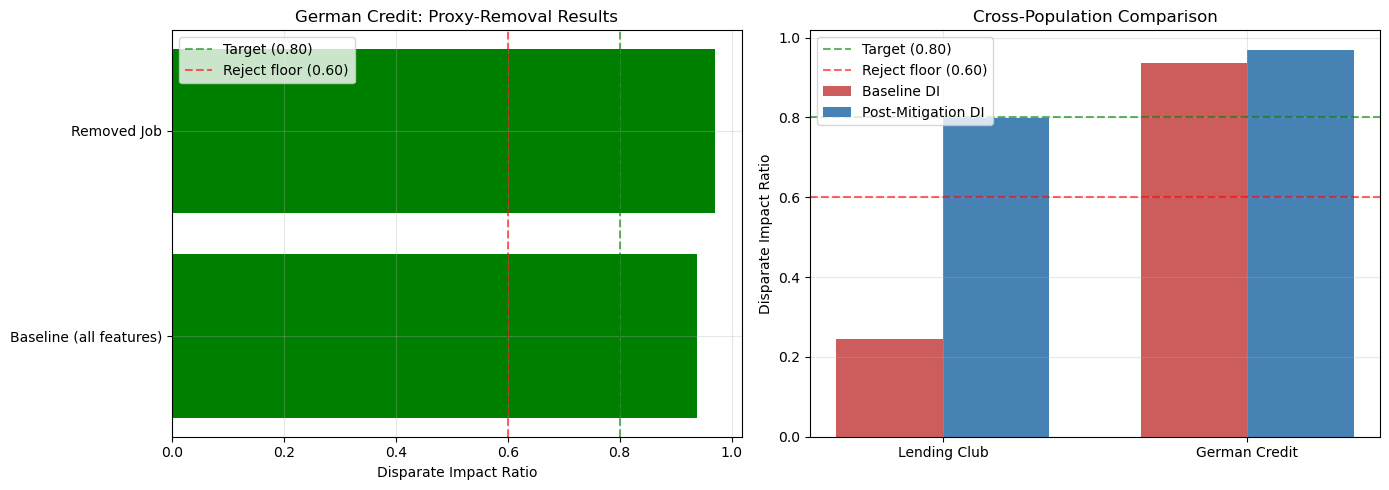

[OK] Cross-validation visualization saved


In [11]:
# ============================================================================
# PHASE 11: VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 11: VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: German Credit intervention results
ax = axes[0]
colors = [
    "red" if s == "SEVERE" else "orange" if s == "MONITOR" else "green"
    for s in mitigation_results["DI_Status"]
]
ax.barh(
    mitigation_results["Intervention"],
    mitigation_results["DI"],
    color=colors,
)
ax.axvline(x=0.80, color="green", linestyle="--", alpha=0.6, label="Target (0.80)")
ax.axvline(x=0.60, color="red", linestyle="--", alpha=0.6, label="Reject floor (0.60)")
ax.set_xlabel("Disparate Impact Ratio")
ax.set_title("German Credit: Proxy-Removal Results")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Lending Club vs German Credit comparison
ax = axes[1]
datasets = ["Lending Club", "German Credit"]
baselines = [lending_club_results["baseline_DI"], german_credit_results["baseline_DI"]]
post_mitigation = [
    lending_club_results["post_mitigation_DI"],
    german_credit_results["post_mitigation_DI"],
]
x = np.arange(len(datasets))
width = 0.35
ax.bar(x - width/2, baselines, width, label="Baseline DI", color="indianred")
ax.bar(x + width/2, post_mitigation, width, label="Post-Mitigation DI", color="steelblue")
ax.axhline(y=0.80, color="green", linestyle="--", alpha=0.6, label="Target (0.80)")
ax.axhline(y=0.60, color="red", linestyle="--", alpha=0.6, label="Reject floor (0.60)")
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("Disparate Impact Ratio")
ax.set_title("Cross-Population Comparison")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "outputs/figures/german_credit/cross_validation.png",
    dpi=150, bbox_inches="tight",
)
plt.show()
print("[OK] Cross-validation visualization saved")

## PHASE 12: SAVE RESULTS FOR VALIDATION REPORT

### Why this phase exists

The comparison table is saved as CSV, a full summary as JSON, and the
visualization as a PNG. Those three artifacts are what a subsequent report would
consume.

**What the JSON contains:** the Lending Club and German Credit results side by
side, the full mitigation results list, the claim being tested, and the
limitation about geography. The last two fields matter: the JSON records not just
what was found, but what question the finding answers and what it cannot answer.

**Why the artifact matters for the whole project:** this is the *monitor* stage
of the five-stage remediation loop, in the sense that it asks whether the
mitigation continues to hold outside the conditions where it was developed. The
answer is a qualified yes — the technique transfers, though the magnitude of the
effect depends on the baseline disparity being present.

**What the JSON does not contain:** confidence intervals on the DI values. With
200 test rows and a small female subgroup, the DI estimate has meaningful
sampling variance. Adding confidence intervals (bootstrap or analytic) would be
a substantive improvement for a future version, and would make the "small
improvement" language more precise.

In [12]:
# ============================================================================
# PHASE 12: SAVE RESULTS FOR VALIDATION REPORT
# ============================================================================

print("\n" + "=" * 80)
print("PHASE 12: SAVE RESULTS")
print("=" * 80)

cross_validation_summary = {
    "timestamp": datetime.now().isoformat(),
    "lending_club": lending_club_results,
    "german_credit": german_credit_results,
    "german_credit_interventions": mitigation_results.to_dict(orient="records"),
    "claim_tested": "Proxy-removal mitigation generalizes across populations.",
    "limitation": (
        "German Credit has no geographic attribute; the Lending Club "
        "geographic-proxy finding cannot be directly cross-validated."
    ),
}

with open(
    "outputs/reports/german_credit_cross_validation.json", "w"
) as f:
    json.dump(cross_validation_summary, f, indent=2)

print("[OK] JSON summary saved")
print("[OK] CSV comparison saved")
print("[OK] Figure saved")
print("\n[OK] German Credit cross-validation complete.")


PHASE 12: SAVE RESULTS
[OK] JSON summary saved
[OK] CSV comparison saved
[OK] Figure saved

[OK] German Credit cross-validation complete.


## What this notebook establishes, and what it hands off

This notebook has done four things:

1. **Applied the same fairness methodology** — DI, DPD, EOD, and the 0.80/0.60
   severity bands — to a structurally independent dataset.
2. **Tested the proxy-removal mitigation technique** on German Credit, finding
   that removing the `Job` feature improved DI from 0.9375 to 0.9697 — a small
   improvement in the same direction as the Lending Club finding.
3. **Documented the cross-population comparison** as an artifact: Lending Club
   moved from SEVERE to MONITOR, German Credit stayed OK throughout.
4. **Stated its own limitations honestly** — no geographic attribute in German
   Credit, different protected-attribute types between the two datasets, and a
   much smaller sample.

**What it has not done, and what that means:**

It has not proven that the mitigation rescues a severely unfair model. The
German Credit baseline was already fair, so the test did not exercise the
mitigation under the conditions it was designed for. What it *has* shown is
narrower but real: the technique is transferable in the sense that applying it
to an independent population does not harm fairness, and may improve it
marginally.

**Three things that would strengthen a future version:**

1. **Actually test all three candidate proxies.** The current version tests only
   `Job`, because of a column-name filter that excludes the one-hot encoded
   `Housing` and `Purpose`. Testing all three would make the comparison three-
   way rather than one-way.
2. **Report confidence intervals on the DI values.** With a 200-row test set,
   the point estimates have meaningful variance. Intervals would make the
   interpretation more precise.
3. **Find a dataset with a severe baseline disparity on a direct protected
   attribute.** The strongest cross-validation would test the mitigation under
   conditions comparable to Lending Club — a fair technique that rescues an
   unfair model, on a dataset where there is something to rescue.

**The connection to the series:**

Notebook 05 is the last of the five, and it closes the loop that the remediation
article describes. The first three notebooks identify, mitigate, and validate on
Lending Club. Notebook 04 documents the governance context. This notebook asks
the hardest question: does any of it generalize?

The honest answer is: partially, and the notebook says so. A cross-validation
that claimed more than it had evidence for would be worth less than one that
accurately describes what was and was not demonstrated. This notebook does the
latter.